# HR Employee Analytics - Exploratory Data Analysis

This notebook explores the synthetic HR employee dataset: dataset overview,
data quality checks, HR KPIs, and analysis of factors associated with
employee attrition.

**Dataset:** `data/hr_employee_data.csv` (synthetic, generated by `src/data_generator.py`)


In [1]:
# Setup
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from analysis import (
    calculate_kpis, attrition_rate_by, add_age_group, add_salary_range,
    add_experience_group, attrition_heatmap_data, correlation_summary,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

DATA_PATH = os.path.join('..', 'data', 'hr_employee_data.csv')
df = pd.read_csv(DATA_PATH)
df.shape

(1200, 30)

## 1. Dataset Overview

In [2]:
print(f"Number of employees: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

numeric_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")

Number of employees: 1200
Number of columns: 30

Numeric columns (20): ['Age', 'Education', 'JobLevel', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'TotalWorkingYears', 'MonthlyIncome', 'HourlyRate', 'JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance', 'PerformanceRating', 'TrainingTimesLastYear', 'NumCompaniesWorked', 'DistanceFromHome', 'JobInvolvement', 'StockOptionLevel', 'PromotionLast5Years']

Categorical columns (10): ['EmployeeID', 'Gender', 'Department', 'JobRole', 'EducationField', 'MaritalStatus', 'OverTime', 'BusinessTravel', 'EmploymentType', 'Attrition']


/tmp/ipykernel_684/2245848388.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


In [3]:
df.head()

,EmployeeID,Age,Gender,Department,JobRole,Education,EducationField,MaritalStatus,JobLevel,YearsAtCompany,...,BusinessTravel,PerformanceRating,TrainingTimesLastYear,NumCompaniesWorked,DistanceFromHome,JobInvolvement,StockOptionLevel,PromotionLast5Years,EmploymentType,Attrition
0,EMP00001,58,Male,Human Resources,HR Manager,2,Medical,Married,5,35,...,Travel_Rarely,3,6,7,20,3,0,0,Full-Time,No
1,EMP00002,48,Female,Research & Development,Healthcare Representative,4,Technical Degree,Divorced,4,8,...,Travel_Frequently,1,3,2,34,2,0,0,Full-Time,No
2,EMP00003,34,Male,Sales,Sales Executive,2,Technical Degree,Single,3,7,...,Travel_Rarely,3,5,2,12,2,0,1,Full-Time,No
3,EMP00004,27,Male,Research & Development,Healthcare Representative,2,Marketing,Married,1,2,...,Travel_Rarely,4,4,0,16,3,0,1,Full-Time,No
4,EMP00005,40,Male,Research & Development,Research Director,4,Marketing,Married,4,4,...,Travel_Rarely,3,3,7,5,4,2,1,Full-Time,No


In [4]:
df.describe()

,Age,Education,JobLevel,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,TotalWorkingYears,MonthlyIncome,HourlyRate,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,WorkLifeBalance,PerformanceRating,TrainingTimesLastYear,NumCompaniesWorked,DistanceFromHome,JobInvolvement,StockOptionLevel,PromotionLast5Years
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,39.990000,2.997500,3.432500,10.557500,5.879167,3.933333,18.562500,76421.345000,65.040000,2.812500,2.817500,2.865833,2.78250,2.992500,2.925833,3.499167,20.262500,2.728333,0.901667,0.620000
std,11.719258,1.103861,1.391782,8.493732,5.930054,4.787448,11.730477,25631.821055,19.956501,1.025453,1.014915,1.018347,0.88554,0.726556,1.955382,2.250011,11.016491,0.868039,0.988000,0.485589
min,20.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,28120.000000,30.000000,1.000000,1.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,30.000000,2.000000,2.000000,4.000000,1.000000,0.000000,8.000000,55489.750000,48.000000,2.000000,2.000000,2.000000,2.00000,3.000000,1.000000,2.000000,11.000000,2.000000,0.000000,0.000000
50%,41.000000,3.000000,4.000000,9.000000,4.000000,2.000000,19.000000,78747.500000,66.000000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.500000,21.000000,3.000000,1.000000,1.000000
75%,50.000000,4.000000,5.000000,16.000000,8.000000,6.000000,29.000000,95445.750000,82.000000,4.000000,4.000000,4.000000,3.00000,3.000000,5.000000,5.000000,29.250000,3.000000,1.000000,1.000000
max,59.000000,5.000000,5.000000,35.000000,31.000000,26.000000,39.000000,125496.000000,99.000000,4.000000,4.000000,4.000000,4.00000,4.000000,6.000000,7.000000,39.000000,4.000000,3.000000,1.000000


## 2. Data Quality

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values:" if not missing.empty else "No missing values found.")
missing

No missing values found.


Series([], dtype: int64)

In [6]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


In [7]:
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values -> {sorted(df[col].unique())[:8]}")

EmployeeID: 1200 unique values -> ['EMP00001', 'EMP00002', 'EMP00003', 'EMP00004', 'EMP00005', 'EMP00006', 'EMP00007', 'EMP00008']
Gender: 2 unique values -> ['Female', 'Male']
Department: 3 unique values -> ['Human Resources', 'Research & Development', 'Sales']
JobRole: 11 unique values -> ['HR Manager', 'Healthcare Representative', 'Human Resources', 'Laboratory Technician', 'Manufacturing Director', 'Recruiter', 'Research Director', 'Research Scientist']
EducationField: 6 unique values -> ['Human Resources', 'Life Sciences', 'Marketing', 'Medical', 'Other', 'Technical Degree']
MaritalStatus: 3 unique values -> ['Divorced', 'Married', 'Single']
OverTime: 2 unique values -> ['No', 'Yes']
BusinessTravel: 3 unique values -> ['Non-Travel', 'Travel_Frequently', 'Travel_Rarely']
EmploymentType: 3 unique values -> ['Contract', 'Full-Time', 'Part-Time']
Attrition: 2 unique values -> ['No', 'Yes']


## 3. HR KPIs

In [8]:
kpis = calculate_kpis(df)
for k, v in kpis.items():
    print(f"{k.replace('_', ' ').title()}: {v}")

Total Employees: 1200
Employees Left: 227
Attrition Rate: 18.9
Avg Age: 40.0
Avg Monthly Income: 76421.0
Avg Experience: 18.6
Avg Job Satisfaction: 2.81
Avg Training Hours: 2.9


## 4. Attrition Analysis

Working through each of the requested attrition breakdowns. Each chart is
generated live from the dataset, not decorative.

### 4.1 Attrition by Department

,Department,Total,Left,AttritionRate
0,Human Resources,148,33,22.3
1,Research & Development,659,128,19.4
2,Sales,393,66,16.8


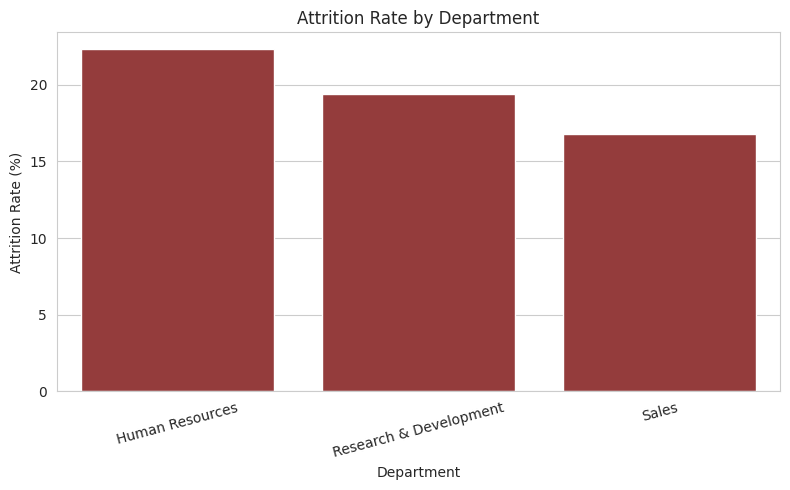

In [9]:
dept_attr = attrition_rate_by(df, 'Department')
display(dept_attr)

plt.figure()
sns.barplot(data=dept_attr, x='Department', y='AttritionRate', color='#A32D2D')
plt.title('Attrition Rate by Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 4.2 Attrition by Job Role

,JobRole,Total,Left,AttritionRate
0,HR Manager,45,13,28.9
5,Recruiter,59,13,22.0
6,Research Director,145,31,21.4
9,Sales Manager,137,27,19.7
1,Healthcare Representative,142,28,19.7
4,Manufacturing Director,132,25,18.9
3,Laboratory Technician,129,24,18.6
7,Research Scientist,111,20,18.0
8,Sales Executive,125,20,16.0
2,Human Resources,44,7,15.9


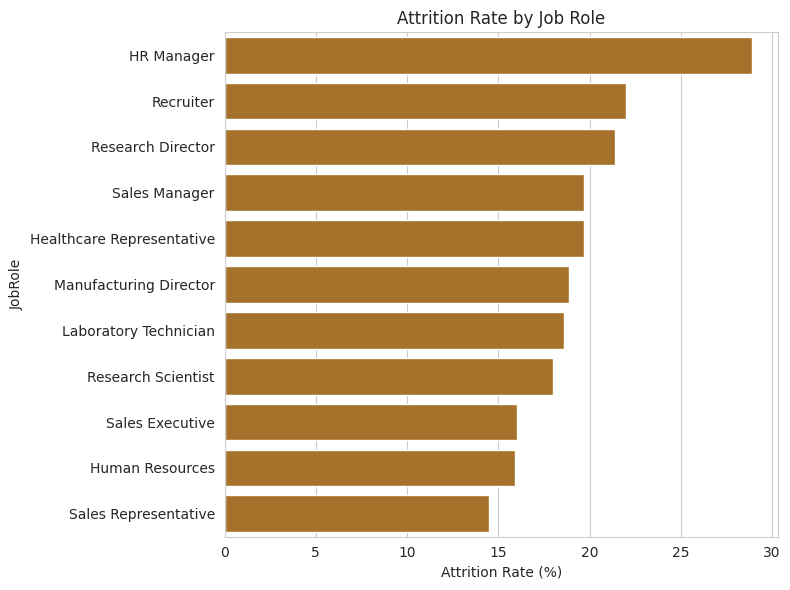

In [10]:
role_attr = attrition_rate_by(df, 'JobRole')
display(role_attr)

plt.figure(figsize=(8, 6))
sns.barplot(data=role_attr, y='JobRole', x='AttritionRate', color='#BA7517')
plt.title('Attrition Rate by Job Role')
plt.xlabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

### 4.3 Attrition by Gender

,Gender,Total,Left,AttritionRate
1,Male,691,139,20.1
0,Female,509,88,17.3


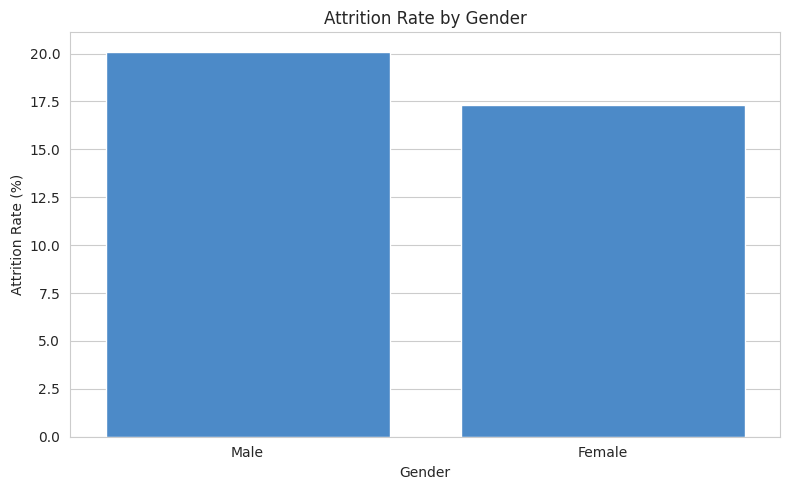

In [11]:
gender_attr = attrition_rate_by(df, 'Gender')
display(gender_attr)

plt.figure()
sns.barplot(data=gender_attr, x='Gender', y='AttritionRate', color='#378ADD')
plt.title('Attrition Rate by Gender')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

### 4.4 Attrition by Age Group

,AgeGroup,Total,Left,AttritionRate
0,18-25,186,64,34.4
1,26-35,266,74,27.8
2,36-45,307,44,14.3
3,46-55,314,34,10.8
4,56+,127,11,8.7


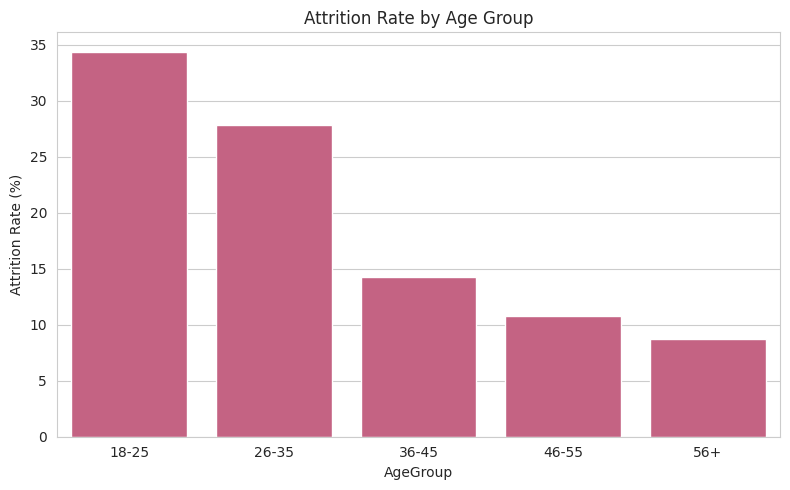

In [12]:
df = add_age_group(df)
age_attr = attrition_rate_by(df, 'AgeGroup').sort_values('AgeGroup')
display(age_attr)

plt.figure()
sns.barplot(data=age_attr, x='AgeGroup', y='AttritionRate', color='#D4537E')
plt.title('Attrition Rate by Age Group')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

### 4.5 Attrition by Salary Range

,SalaryRange,Total,Left,AttritionRate
0,<30k,17,9,52.9
1,30k-50k,211,78,37.0
2,50k-70k,257,60,23.3
3,70k-100k,470,62,13.2
4,100k+,245,18,7.3


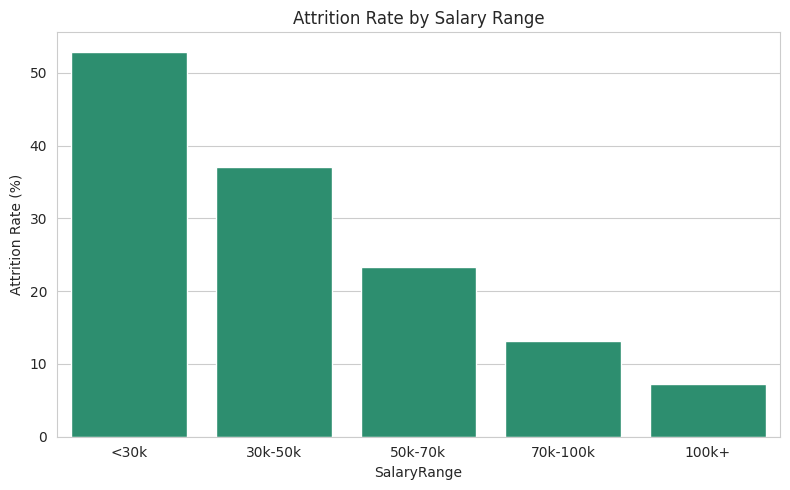

In [13]:
df = add_salary_range(df)
salary_attr = attrition_rate_by(df, 'SalaryRange').sort_values('SalaryRange')
display(salary_attr)

plt.figure()
sns.barplot(data=salary_attr, x='SalaryRange', y='AttritionRate', color='#1D9E75')
plt.title('Attrition Rate by Salary Range')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

### 4.6 Attrition by Years at Company

,YearsAtCompanyGroup,Total,Left,AttritionRate
0,0-1,191,66,34.6
1,2-3,96,32,33.3
2,4-6,166,40,24.1
3,7-10,239,36,15.1
4,10+,508,53,10.4


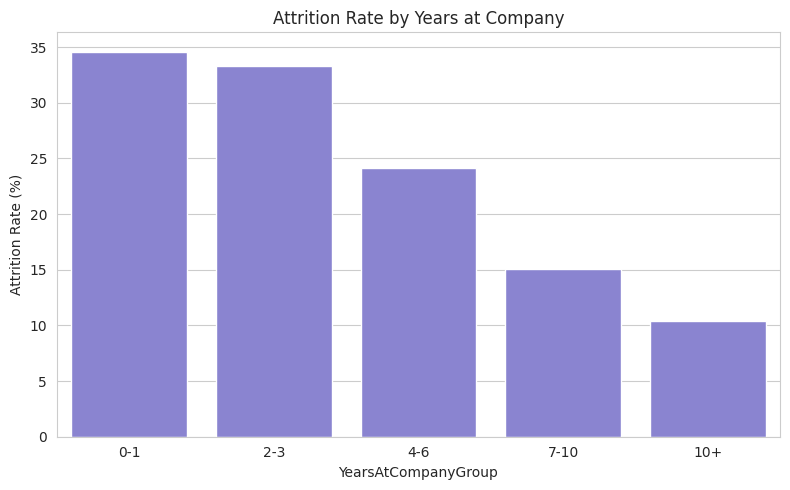

In [14]:
df = add_experience_group(df)
years_attr = attrition_rate_by(df, 'YearsAtCompanyGroup').sort_values('YearsAtCompanyGroup')
display(years_attr)

plt.figure()
sns.barplot(data=years_attr, x='YearsAtCompanyGroup', y='AttritionRate', color='#7F77DD')
plt.title('Attrition Rate by Years at Company')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

### 4.7 Attrition by Overtime

,OverTime,Total,Left,AttritionRate
1,Yes,347,111,32.0
0,No,853,116,13.6


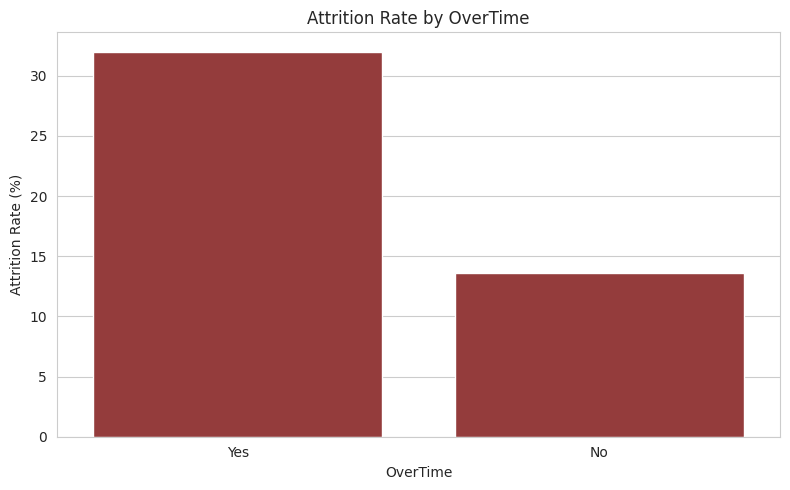

In [15]:
ot_attr = attrition_rate_by(df, 'OverTime')
display(ot_attr)

plt.figure()
sns.barplot(data=ot_attr, x='OverTime', y='AttritionRate', color='#A32D2D')
plt.title('Attrition Rate by OverTime')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

### 4.8 Attrition by Job Satisfaction

,JobSatisfaction,Total,Left,AttritionRate
0,1,181,59,32.6
1,2,221,48,21.7
2,3,440,71,16.1
3,4,358,49,13.7


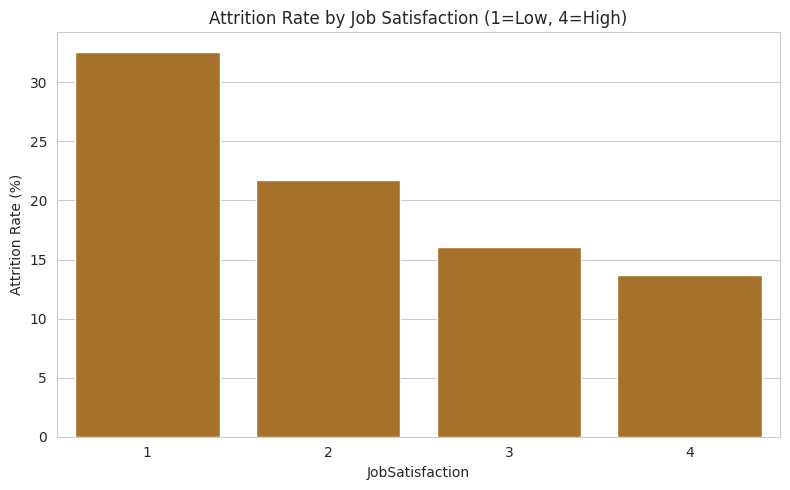

In [16]:
sat_attr = attrition_rate_by(df, 'JobSatisfaction').sort_values('JobSatisfaction')
display(sat_attr)

plt.figure()
sns.barplot(data=sat_attr, x='JobSatisfaction', y='AttritionRate', color='#BA7517')
plt.title('Attrition Rate by Job Satisfaction (1=Low, 4=High)')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

### 4.9 Attrition by Work-Life Balance

,WorkLifeBalance,Total,Left,AttritionRate
0,1,112,26,23.2
1,2,293,73,24.9
2,3,539,94,17.4
3,4,256,34,13.3


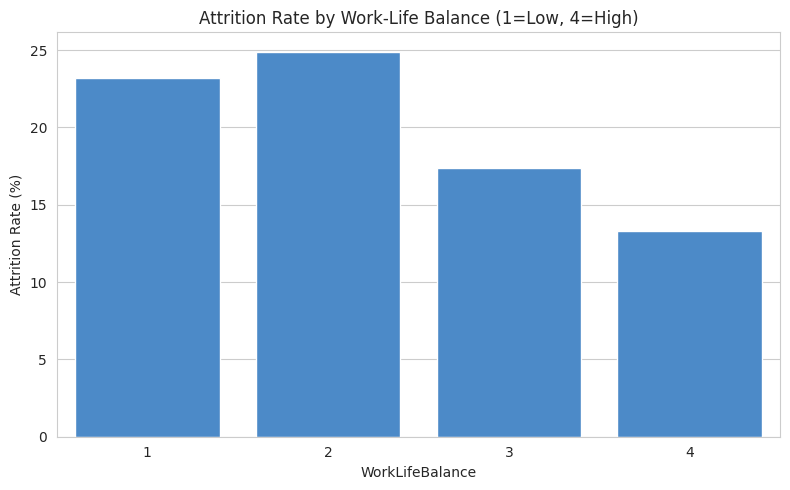

In [17]:
wlb_attr = attrition_rate_by(df, 'WorkLifeBalance').sort_values('WorkLifeBalance')
display(wlb_attr)

plt.figure()
sns.barplot(data=wlb_attr, x='WorkLifeBalance', y='AttritionRate', color='#378ADD')
plt.title('Attrition Rate by Work-Life Balance (1=Low, 4=High)')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

### 4.10 Attrition by Promotion History

,PromotionLast5Years,Total,Left,AttritionRate
0,Not Promoted,456,107,23.5
1,Promoted,744,120,16.1


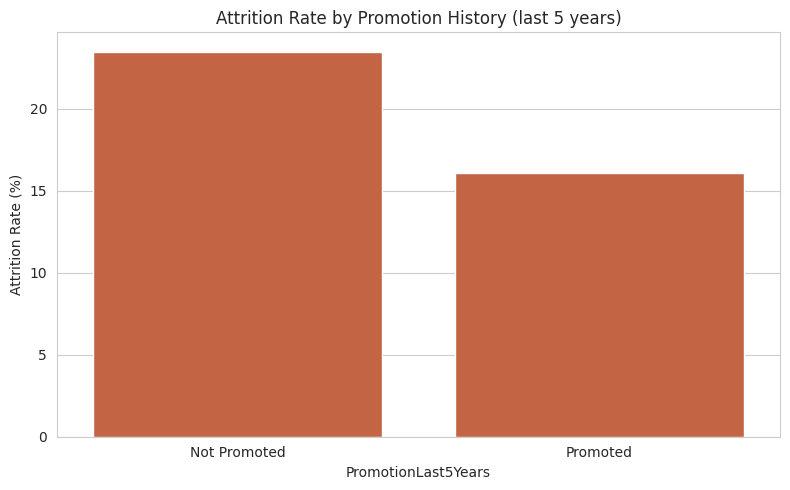

In [18]:
promo_attr = attrition_rate_by(df, 'PromotionLast5Years')
promo_attr['PromotionLast5Years'] = promo_attr['PromotionLast5Years'].map({1: 'Promoted', 0: 'Not Promoted'})
display(promo_attr)

plt.figure()
sns.barplot(data=promo_attr, x='PromotionLast5Years', y='AttritionRate', color='#D85A30')
plt.title('Attrition Rate by Promotion History (last 5 years)')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

### 4.11 Attrition by Business Travel

,BusinessTravel,Total,Left,AttritionRate
1,Travel_Frequently,265,65,24.5
2,Travel_Rarely,809,142,17.6
0,Non-Travel,126,20,15.9


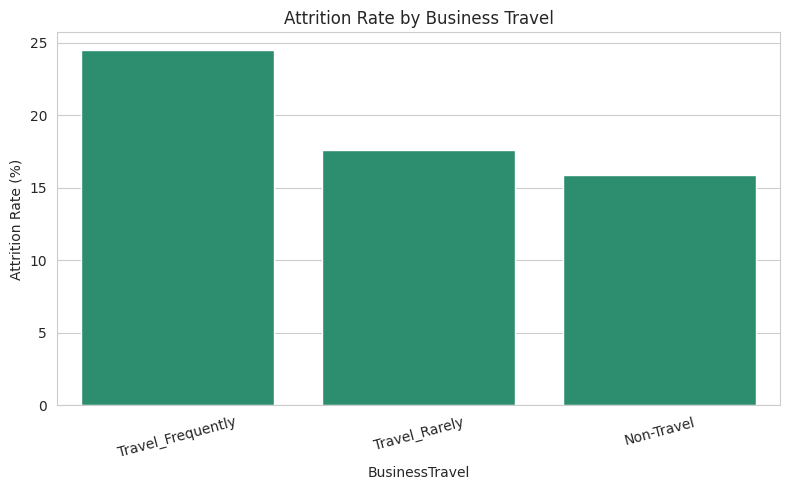

In [19]:
travel_attr = attrition_rate_by(df, 'BusinessTravel')
display(travel_attr)

plt.figure()
sns.barplot(data=travel_attr, x='BusinessTravel', y='AttritionRate', color='#1D9E75')
plt.title('Attrition Rate by Business Travel')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 4.12 Attrition by Job Level

,JobLevel,Total,Left,AttritionRate
0,1,134,58,43.3
1,2,227,63,27.8
2,3,210,41,19.5
3,4,244,30,12.3
4,5,385,35,9.1


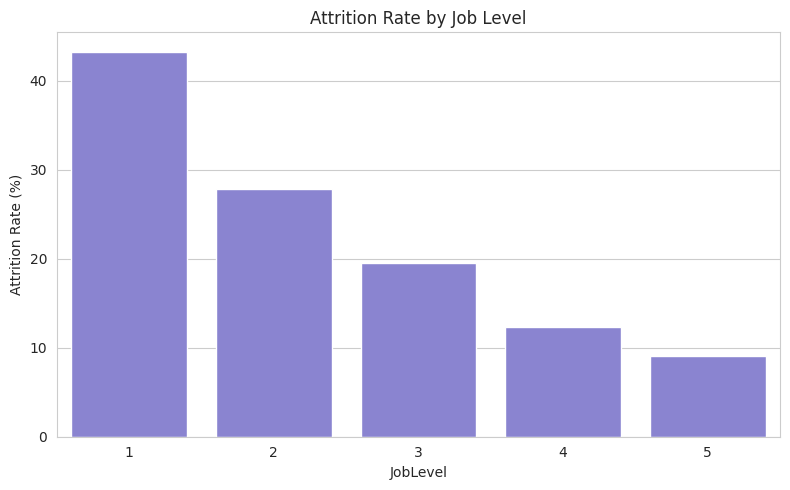

In [20]:
level_attr = attrition_rate_by(df, 'JobLevel').sort_values('JobLevel')
display(level_attr)

plt.figure()
sns.barplot(data=level_attr, x='JobLevel', y='AttritionRate', color='#7F77DD')
plt.title('Attrition Rate by Job Level')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

## 5. Attrition Heatmap: Job Role x Department

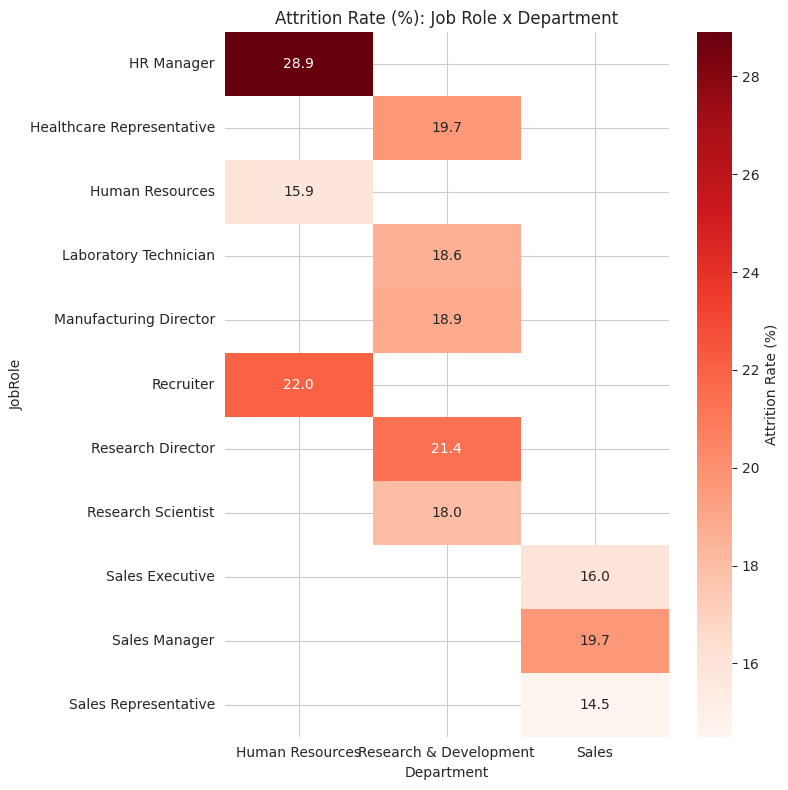

In [21]:
heatmap_data = attrition_heatmap_data(df)

plt.figure(figsize=(8, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': 'Attrition Rate (%)'})
plt.title('Attrition Rate (%): Job Role x Department')
plt.tight_layout()
plt.show()

## 6. Correlation of Numeric Features with Attrition

DistanceFromHome            0.058241
Education                   0.033877
TrainingTimesLastYear       0.027037
PerformanceRating           0.004988
RelationshipSatisfaction   -0.003228
HourlyRate                 -0.005342
NumCompaniesWorked         -0.008809
JobInvolvement             -0.015527
EnvironmentSatisfaction    -0.028467
StockOptionLevel           -0.035934
PromotionLast5Years        -0.090918
WorkLifeBalance            -0.100065
YearsSinceLastPromotion    -0.144004
JobSatisfaction            -0.154521
YearsInCurrentRole         -0.177175
YearsAtCompany             -0.224191
TotalWorkingYears          -0.242927
Age                        -0.243349
JobLevel                   -0.270987
MonthlyIncome              -0.278707
Name: AttritionFlag, dtype: float64

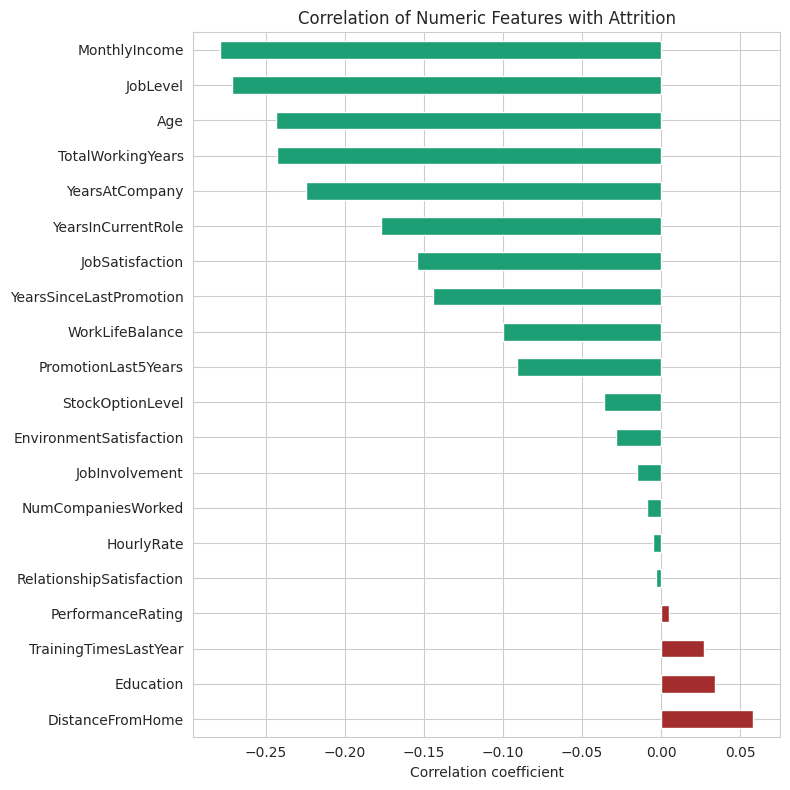

In [22]:
corr = correlation_summary(df)
display(corr)

plt.figure(figsize=(8, 8))
corr.plot(kind='barh', color=['#A32D2D' if v > 0 else '#1D9E75' for v in corr.values])
plt.title('Correlation of Numeric Features with Attrition')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

## 7. Summary

This exploratory analysis surfaces the same attrition risk factors used to
generate the synthetic data: overtime, low job satisfaction, low work-life
balance, lower income, shorter tenure, longer commutes, and frequent business
travel are all associated with higher attrition rates in this dataset. These
findings carry through into the SQL analysis (`sql/hr_queries.sql`), the
business insights report (`reports/business_insights.md`), and the machine
learning model (`src/prediction.py`).
